# Notebook 03 — Race/equity analysis (Figs. 4, 6)

Reproduces the two race-equity figures from *Trajectory-Integrated Public EVCS Accessibility (TI-acs)*:

- **Fig. 4** (`fig:race`, §3.5): CDFs of tract-level TI-acs [hours] by **dominant racial/ethnic group** in 2024 (MUD subset) + 2012–2024 trend of the race-effect regression coefficient.
- **Fig. 6** (`fig:race-reg-appx`, §4 Discussion): same regression as Fig. 4 but for **robustness across income controls** — comparing no-income, linear, and 4th-order ln(income) controls, decomposed by stay-location segment.

Both figures rest on the regression of paper §2.2:

$$y_j = \sum_r \beta_r\,\delta_{jr} + \beta_I\,\log I_j + \beta_0 + \epsilon_j,$$

where $y_j$ is the tract-level TI-acs metric, $\delta_{jr}$ flags the *dominant* race in tract $j$, and $I_j$ is the median household income.

The full regression code lives inline (§ "Inline OLS regression" below) so the reader can audit it. For speed in the year-by-year multi-figure loops we additionally ship cached results in `data/race_regression_I{0,1,4}.xlsx`.


In [1]:
# Configuration ---------------------------------------------------------------
DIST                    = 1000             # m. Only 1000 m is stored in the data file.
YEAR_FOCUS              = 2024             # year for the CDF in Fig. 4 a/b
YEAR_RANGE              = list(range(2012, 2025))   # year sweep for the coefficient trend
SUBSET                  = "MUD"            # "MUD" | "Renter" | None — restrict tracts
DOMINANT_RACE_THRESHOLD = 40               # %; race is "dominant" if both largest AND ≥ this %
INCOME_QUANTILES        = 5                # used for the income-group split (not central here)

# Income-control variants featured in Fig. 6.
# I=0  : no ln(income) control
# I=1  : linear ln(income)
# I=4  : quartic ln(income) (i.e., adds ln, ln², ln³, ln⁴ terms)
INCOME_CONTROL_ORDERS   = [0, 1, 4]

MIN_TRACT_POP           = 500

# === Alternative configurations supported by the shipped data ===============
# DIST       ∈ {1000}
# SUBSET     ∈ {"MUD", "Renter", None}
# DOMINANT_RACE_THRESHOLD: any percentage in (0, 100); 40 is the paper choice
# INCOME_CONTROL_ORDERS: cached results shipped for {0, 1, 4}; other orders
#   can be recomputed by the inline `fit_race_regression` below.
# YEAR_RANGE ⊆ 2012..2024 (ACS uses 2022 values for years > 2022)


In [2]:
# Imports & path setup --------------------------------------------------------
import sys, os
_repo = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _repo not in sys.path:
    sys.path.insert(0, _repo)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.api as sm

from ti_acs import io, plotting
from ti_acs.style import RACE_COLORS, RACE_LABELS

FIG_DIR = os.path.join(_repo, "outputs", "figs")
os.makedirs(FIG_DIR, exist_ok=True)


## Load TI-acs and ACS demographics


In [3]:
# Load + clean ----------------------------------------------------------------
io.validate_config("hours_annual", years=YEAR_RANGE, dists=[DIST])

stats_dfs = io.load_tract_stats("hours_annual")
pop = stats_dfs["num_users"]["num_users"]
keep_idx = pop[pop > MIN_TRACT_POP].index
zone_stats = stats_dfs["mean"].loc[keep_idx] * 24   # hours per day

acs_dfs = io.load_acs_demographics()
print(f"Tracts after filter: {len(zone_stats)}")
print(f"ACS variables: {list(acs_dfs)[:5]} ...")


Tracts after filter: 1428
ACS variables: ['Pop_tot', 'Pop_over_18_tot', 'Pop_Hispanic_pct', 'Pop_White_nonHis_pct', 'Pop_Black_nonHis_pct'] ...


## Demographic-group assignment (paper §3.5)

A racial/ethnic group is **dominant** in a tract if it is both the largest AND constitutes ≥ `DOMINANT_RACE_THRESHOLD` % of the population. We also derive an income quintile and two housing-stock flags (`more_MUD`, `more_renters`). All flags reference the ACS estimate of the matching year, falling back to 2022 for years beyond ACS coverage.

This is the core methodological step linking accessibility to community demographics — kept inline.


In [4]:
# Inline demographic-group assignment (paper §3.5) ----------------------------
def acs_features_for_year(acs_dfs, year, dominant_thres=DOMINANT_RACE_THRESHOLD,
                          income_quantiles=INCOME_QUANTILES):
    # Stack each ACS sheet's column for the chosen year into a tract × variable
    # DataFrame. Beyond 2022 the ACS only has 2022 estimates, so we cap.
    year = min(year, 2022)
    yr_df = pd.concat([acs_dfs[k][year] for k in acs_dfs], axis=1, keys=acs_dfs.keys())

    # Dominant race / ethnicity (paper §3.5 footnote treats Hispanic as a
    # cultural/ethnic identity, not a biological race).
    races = ["White_nonHis", "Black_nonHis", "Asian_nonHis", "Hispanic"]
    pct_cols = [f"Pop_{r}_pct" for r in races]
    def _dominant(row):
        vals = row[pct_cols].astype(float)
        if vals.isna().all():
            return "No-dominant"
        # argmax of NumPy array sidesteps NaN-column-name ambiguity that
        # idxmax can hit when all values are NaN; we already guarded above.
        i = int(np.nanargmax(vals.values))
        return races[i] if vals.values[i] > dominant_thres else "No-dominant"
    yr_df["dominant_race"] = yr_df.apply(_dominant, axis=1)

    # Income quintile (1..income_quantiles).
    inc = yr_df["Income_Household_med"].astype(float)
    qs = inc.quantile(np.linspace(0, 1, income_quantiles + 1)[1:-1])
    yr_df["income_group"] = sum((inc >= q).astype(int) for q in qs)

    # Housing-stock flags used for the MUD / Renter subset selection.
    yr_df["more_renters"] = (yr_df["House_Renter_pct"].astype(float) > 50)
    yr_df["more_MUD"]     = (yr_df["House_Detached_pct"].astype(float) <= 50)
    return yr_df

acs_focus = acs_features_for_year(acs_dfs, YEAR_FOCUS)
print(acs_focus["dominant_race"].value_counts())
print(f"\nMUD tracts: {acs_focus['more_MUD'].sum()} of {len(acs_focus)}")


dominant_race
White_nonHis    3878
Hispanic        3543
No-dominant      865
Asian_nonHis     749
Black_nonHis      94
Name: count, dtype: int64

MUD tracts: 2319 of 9129


## Inline OLS regression (paper §2.2, eq. 6)

For a given (year, level, distance, segment, subset) we estimate

$$y_j = \sum_r \beta_r\,\delta_{jr} + \sum_{k=1}^{K}\beta_{I,k}(\log I_j)^k + \beta_0 + \epsilon_j$$

with the reference category `No-dominant` (so `β_r` is the average difference vs. tracts without a dominant group). `K` is `control_income_order` (0 for no income control, 1 for linear, 4 for quartic in Fig. 6).


In [5]:
# Regression fitter (inline OLS) ----------------------------------------------
def segment_values(zone_stats, year, level, dist, seg):
    # Single-segment tract values — same partition used in Notebook 02.
    pfx = f"{year}_{level}_{dist}"
    if seg == "all":
        return zone_stats[f"{pfx}_all"]
    if seg == "home":
        return zone_stats[f"{pfx}_home"]
    if seg == "work":
        return zone_stats[f"{pfx}_HnW"] - zone_stats[f"{pfx}_home"]
    if seg == "other":
        return zone_stats[f"{pfx}_all"] - zone_stats[f"{pfx}_HnW"]
    raise ValueError(f"unknown segment {seg!r}")


def fit_race_regression(zone_stats, acs_dfs, year, level, dist, seg,
                        subset=SUBSET, control_income_order=1):
    # Returns a DataFrame indexed by "{year}-{group}" with coef/CI/p-value
    # columns, ready for plotting.plot_race_regression_coefs.
    y_vals = segment_values(zone_stats, year, level, dist, seg)
    acs = acs_features_for_year(acs_dfs, year)

    # Subset selection (MUD / Renter / None).
    if subset == "MUD":
        mask = acs["more_MUD"]
    elif subset == "Renter":
        mask = acs["more_renters"]
    elif subset is None:
        mask = pd.Series(True, index=acs.index)
    else:
        raise ValueError(f"subset must be 'MUD', 'Renter', or None; got {subset!r}")

    # One-hot encode dominant_race; drop No-dominant as reference category.
    X = pd.get_dummies(acs["dominant_race"]).drop(columns=["No-dominant"])
    if control_income_order > 0:
        ln_income = np.log(acs["Income_Household_med"].astype(float) + 1e-6)
        for k in range(1, control_income_order + 1):
            X[f"ln_income^{k}"] = ln_income ** k
    X = X.astype(float)
    X["y"] = y_vals
    X = X[mask].dropna()
    y = X.pop("y")
    X = sm.add_constant(X)

    res = sm.OLS(y, X).fit()
    out = pd.concat([res.params, res.conf_int(), res.pvalues], axis=1)
    out.columns = ["coef", "lo", "hi", "p-value"]
    out.index = [f"{year}-{name}" for name in out.index]
    return out

# Smoke-test: 2024 L2, "all" segment, MUD subset, linear ln(income).
demo = fit_race_regression(zone_stats, acs_dfs, 2024, "L2", DIST, "all",
                           subset="MUD", control_income_order=1)
demo.loc[[f"2024-{g}" for g in ["White_nonHis", "Hispanic", "Black_nonHis", "Asian_nonHis"]]]


,coef,lo,hi,p-value
2024-White_nonHis,1.679145,0.177253,3.181037,0.028513
2024-Hispanic,-3.437353,-5.285093,-1.589612,0.000286
2024-Black_nonHis,-3.677422,-8.364617,1.009773,0.123820
2024-Asian_nonHis,-0.566108,-2.182118,1.049901,0.491556


## Per-year regression results

For the multi-year coefficient panels (Fig. 4 c/d, Fig. 6) we run the fit for every year × level × segment × income-control combination. To keep the notebook fast we *load cached results* by default. The cached files were produced by the inline fitter above with `subset="MUD"`.

Run with `USE_CACHE = False` to recompute from scratch and verify the cache.


In [6]:
# Load cached results (or recompute) ------------------------------------------
USE_CACHE = True   # set to False to recompute fresh

def load_or_fit(income_control_order):
    if USE_CACHE:
        return io.load_cached_race_regression(income_control_order)
    # Recompute from scratch by stacking every (year, level, segment) fit.
    out = {}
    for level in ["L2", "DCFC"]:
        for seg in ["all", "home", "work", "other"]:
            rows = []
            for year in YEAR_RANGE:
                rows.append(fit_race_regression(zone_stats, acs_dfs, year, level, DIST, seg,
                                                subset=SUBSET,
                                                control_income_order=income_control_order))
            out[f"{level}_{seg}"] = pd.concat(rows)
    return out

reg_dfs = {order: load_or_fit(order) for order in INCOME_CONTROL_ORDERS}
print({order: list(reg_dfs[order])[:4] for order in INCOME_CONTROL_ORDERS})


{0: ['L2_all', 'L2_home', 'L2_work', 'L2_other'], 1: ['L2_all', 'L2_home', 'L2_work', 'L2_other'], 4: ['L2_all', 'L2_home', 'L2_work', 'L2_other']}


## Fig. 4 — CDFs by dominant race + headline regression


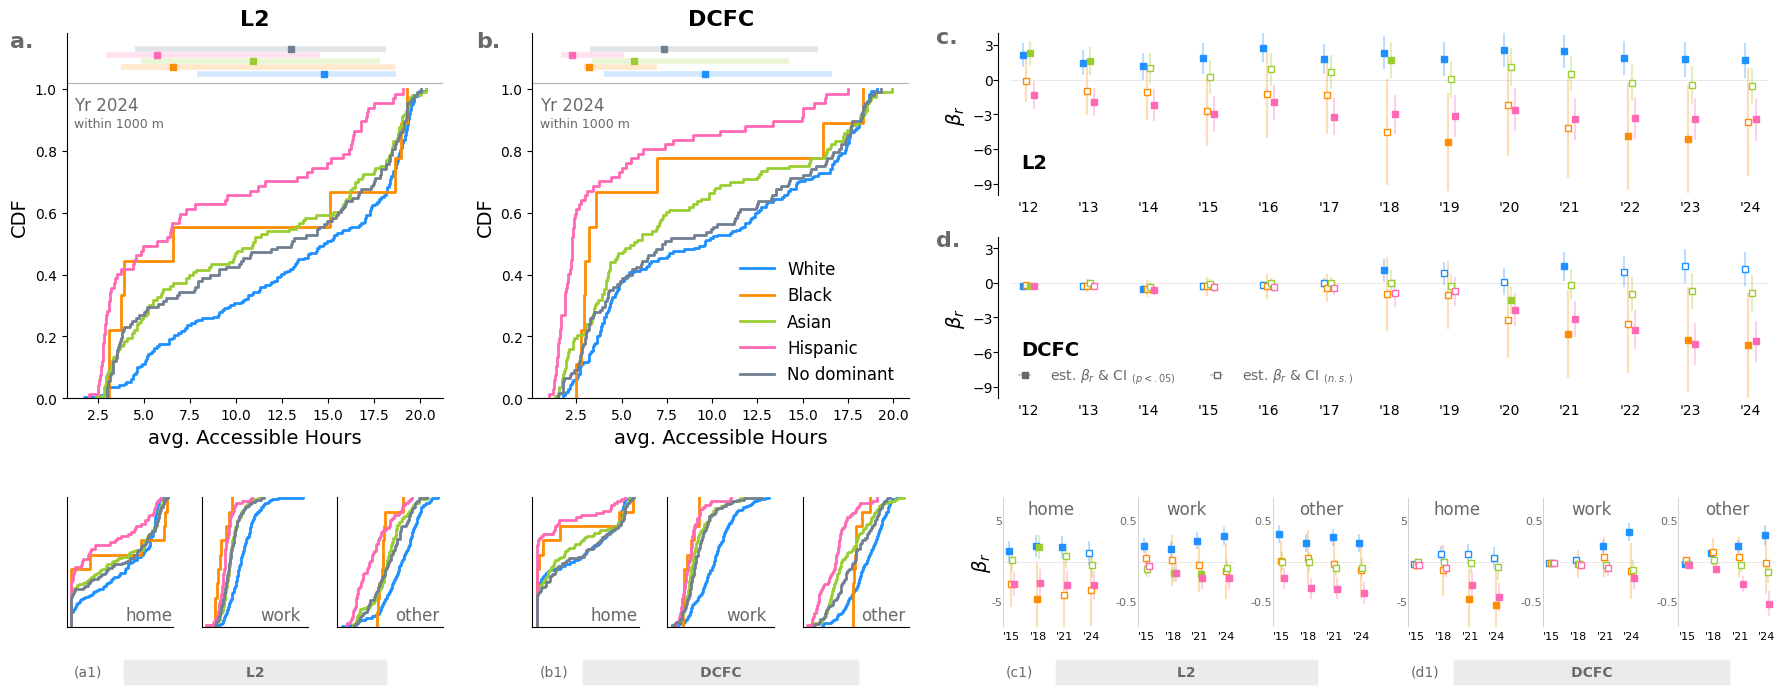

In [7]:
# Assemble Fig. 4 -------------------------------------------------------------
fig = plt.figure(figsize=(18, 7))
gs = gridspec.GridSpec(5, 14, height_ratios=[1, 1, 0.1, 0.8, 0.05],
                        width_ratios=[1]*3 + [0.3] + [1]*3 + [0.3] + [1]*6)

# Pre-compute MUD-subset tract pools.
acs_focus = acs_features_for_year(acs_dfs, YEAR_FOCUS)
mud_mask = acs_focus["more_MUD"]

for i, level in enumerate(["L2", "DCFC"]):
    for j, seg in enumerate(["all", "home", "work", "other"]):
        # CDF: collect tract values per race group, then call plot_race_cdf.
        vals = segment_values(zone_stats, YEAR_FOCUS, level, DIST, seg)
        per_group = {}
        for g in RACE_LABELS:
            tract_ids = acs_focus[(acs_focus["dominant_race"] == g) & mud_mask].index
            per_group[g] = vals.reindex(tract_ids).dropna()

        if j == 0:
            ax = fig.add_subplot(gs[0:2, 4*i:4*i+3])
            plotting.plot_race_cdf(ax, per_group, mark_stats=True)
            ax.set_title(level, fontsize=16, fontweight="bold")
            ax.text(0.02, 0.78, f"Yr {YEAR_FOCUS}", fontsize=12, color="dimgrey",
                    ha="left", va="bottom", transform=ax.transAxes)
            ax.text(0.02, 0.77, f"within {DIST} m", fontsize=9, color="dimgrey",
                    ha="left", va="top", transform=ax.transAxes)
            ax.text(-0.15, 0.98, f"{chr(97+i)}.", fontsize=16, color="dimgrey",
                    fontweight="bold", ha="left", va="center", transform=ax.transAxes)
            if i == 1:
                ax.legend(frameon=False, loc="lower right", fontsize=12)
        else:
            ax = fig.add_subplot(gs[3, 4*i + j - 1])
            plotting.plot_race_cdf(ax, per_group, mark_stats=False)
            ax.set_xlabel("")
            ax.set_xticks([])
            ax.set_ylabel("")
            ax.set_yticks([])
            ax.text(0.55, 0.02, seg, fontsize=12, color="dimgrey", ha="left",
                    va="bottom", transform=ax.transAxes)

# Section labels under the small panels
for i, level in enumerate(["L2", "DCFC"]):
    ax = fig.add_subplot(gs[4, 4*i:4*i+3])
    ax.axis("off")
    ax.text(0.5, 0.5, f"{level:^50}", fontsize=10, color="dimgrey",
            fontweight="bold", ha="center", va="center",
            transform=ax.transAxes,
            bbox=dict(facecolor="silver", edgecolor="white", alpha=0.3))
    ax.text(0.02, 0.5, f"({chr(97+i)}1)", fontsize=10, color="dimgrey",
            ha="left", va="center", transform=ax.transAxes)

# Regression coefficient panels (c, d): "all" segment, all years, I=1
reg_I1 = reg_dfs[1]
for i, level in enumerate(["L2", "DCFC"]):
    ax = fig.add_subplot(gs[i, -6:])
    plotting.plot_race_regression_coefs(
        ax, reg_I1[f"{level}_all"], years=YEAR_RANGE,
        legend=(i == 1), simplified=False,
    )
    ax.text(0.03, 0.2 + 0.1 * i, level, fontsize=14, color="k",
            fontweight="bold", ha="left", va="center", transform=ax.transAxes)
    ax.text(-0.08, 0.98, f"{chr(99+i)}.", fontsize=16, color="dimgrey",
            fontweight="bold", ha="left", va="center", transform=ax.transAxes)

# Per-segment regression coefficient mini-panels (c1, d1): 3 segments per level
# in row 3 of the gridspec, with a level label band in row 4.
for i, level in enumerate(["L2", "DCFC"]):
    ax = fig.add_subplot(gs[4, 8 + 3 * i:8 + 3 * i + 3])
    ax.axis("off")
    ax.text(0.5, 0.5, f"{level:^50}", fontsize=10, color="dimgrey",
            fontweight="bold", ha="center", va="center", transform=ax.transAxes,
            bbox=dict(facecolor="silver", edgecolor="white", alpha=0.3))
    ax.text(0.02, 0.5, f"({chr(99+i)}1)", fontsize=10, color="dimgrey",
            ha="left", va="center", transform=ax.transAxes)
    for j, seg in enumerate(["home", "work", "other"]):
        ax_seg = fig.add_subplot(gs[3, 8 + 3 * i + j])
        # The home segment has much wider β range than work/other; match the
        # paper's per-segment ylim choices for readability.
        ylim = (-8, 8) if seg == "home" else (-0.8, 0.8)
        yticks = [-5, 5] if seg == "home" else [-0.5, 0.5]
        plotting.plot_race_regression_coefs(
            ax_seg, reg_I1[f"{level}_{seg}"],
            years=list(range(2015, 2025, 3)),
            simplified=True, legend=False,
            ylim=ylim, yticks=yticks,
        )
        ax_seg.text(0.5, 0.98, seg, fontsize=12, color="dimgrey",
                    ha="center", va="top", transform=ax_seg.transAxes)
        if 3 * i + j == 0:
            ax_seg.set_ylabel(r"$\beta_r$", fontsize=14)

plt.tight_layout(w_pad=-2, h_pad=-0.5)
fig.savefig(os.path.join(FIG_DIR, "fig4_race.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()


## Fig. 6 — Regression robustness to income controls (Discussion)

Two side-by-side panels: regression with no income term (I=0) on the left, with quartic ln(income) (I=4) on the right. Each panel breaks down by stay segment (home/work/other) below the headline "all" segment.


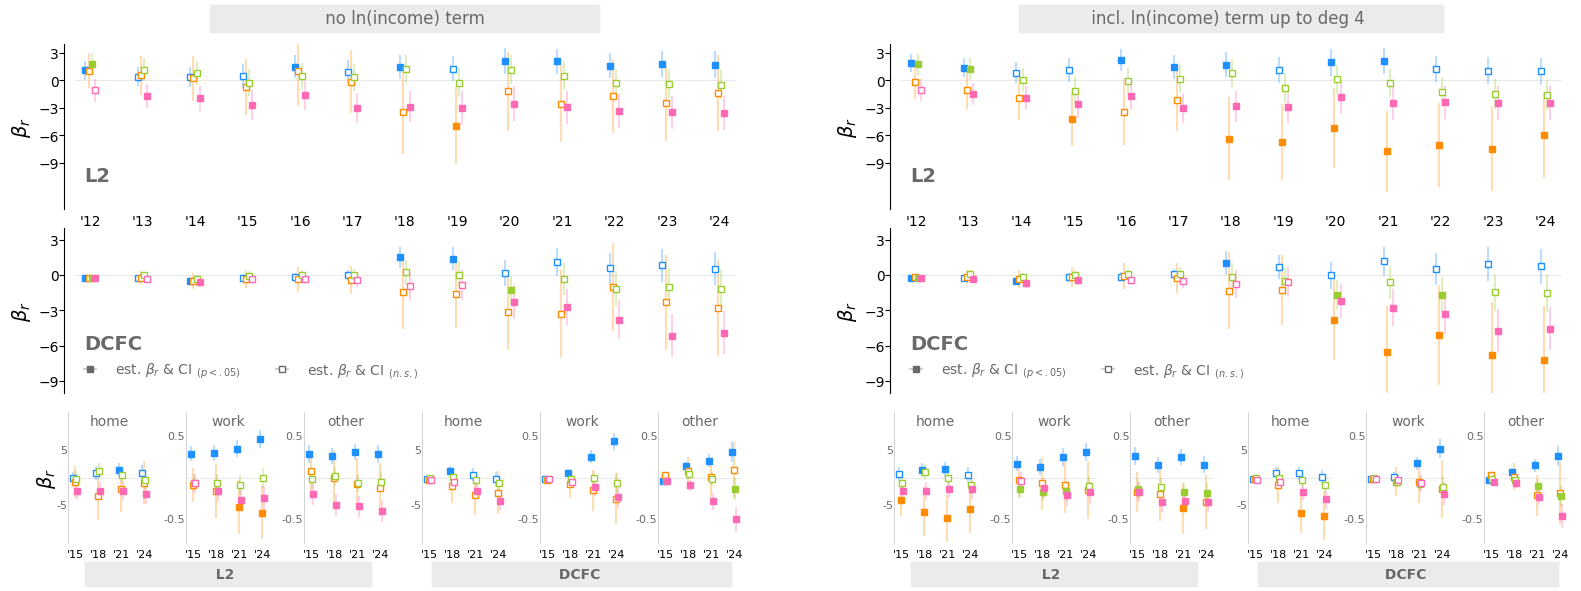

In [8]:
# Assemble Fig. 6 -------------------------------------------------------------
fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(4, 13, height_ratios=[1, 1, 0.8, 0.05])

reg0 = reg_dfs[0]
reg4 = reg_dfs[4]

for k, (reg, label) in enumerate([(reg0, "no ln(income) term"),
                                    (reg4, "incl. ln(income) term up to deg 4")]):
    for i, level in enumerate(["L2", "DCFC"]):
        ax = fig.add_subplot(gs[i, 7*k:7*k + 6])
        plotting.plot_race_regression_coefs(
            ax, reg[f"{level}_all"], years=YEAR_RANGE,
            legend=(i == 1), simplified=False,
        )
        ax.text(0.03, 0.2 + 0.1 * i, level, fontsize=14, color="dimgrey",
                fontweight="bold", ha="left", va="center", transform=ax.transAxes)
        if level == "DCFC":
            ax.set_xticks([])
        if i == 0:
            ax.set_ylim(-14, 4)
            ax.text(0.5, 1.1, f"{label:^60}", fontsize=12, color="dimgrey",
                    ha="center", va="bottom", transform=ax.transAxes,
                    bbox=dict(facecolor="silver", edgecolor="white", alpha=0.3))

    # Per-segment narrow panels
    for i, level in enumerate(["L2", "DCFC"]):
        ax = fig.add_subplot(gs[3, 7*k + 3*i:7*k + 3*i + 3])
        ax.axis("off")
        ax.text(0.5, 0.5, f"{level:^55}", fontsize=10, color="dimgrey",
                fontweight="bold", ha="center", va="top", transform=ax.transAxes,
                bbox=dict(facecolor="silver", edgecolor="white", alpha=0.3))
        for j, seg in enumerate(["home", "work", "other"]):
            ax_seg = fig.add_subplot(gs[2, 7*k + 3*i + j])
            ylim = (-12, 12) if (j == 0) else ((-8, 8) if seg == "home" else (-0.8, 0.8))
            yticks = [-5, 5] if seg == "home" else [-0.5, 0.5]
            plotting.plot_race_regression_coefs(
                ax_seg, reg[f"{level}_{seg}"],
                years=list(range(2015, 2025, 3)),
                simplified=True, legend=False,
                ylim=ylim, yticks=yticks,
            )
            ax_seg.text(0.5, 0.98, seg, fontsize=10, color="dimgrey",
                        ha="center", va="top", transform=ax_seg.transAxes)
            if 7*k + 3*i + j == 0:
                ax_seg.set_ylabel(r"$\beta_r$", fontsize=14)

plt.tight_layout(w_pad=-2, h_pad=0)
fig.savefig(os.path.join(FIG_DIR, "fig6_race_reg_robustness.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
